In [2]:
from pathlib import Path
import sys

from datasets import concatenate_datasets, load_from_disk
from matplotlib.colors import LinearSegmentedColormap
from transformers import AutoTokenizer
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from transformers import AutoTokenizer
import numpy as np
src_dir = Path.cwd().parent.parent
print(src_dir)
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from figures.theme import Colours, Fonts, DISPLAY_NAMES
# CONFIG
MAX_CORES = 8
DISPLAY_SENTIMENT_TAB = False


# MODEL
MODELS = {
    "DeBERTav3": {
        "repo": "microsoft/deberta-v3-base", 
        "sequence_len": 512,
        "lr": 5e-7,
        "weight_decay": 0.01,
        "adam_e": 1e-6,  
        "bf16": False,
        },
    "ModernBERT": {
        "repo": "answerdotai/ModernBERT-base", 
        "sequence_len": 1024,     #2 batch size for 2048
        "lr": 5e-5,     
        "weight_decay": 0.01,
        "adam_e": 1e-8,
        "bf16": True,          
    },
    # "ModernBERT2": {
    #     "repo": "answerdotai/ModernBERT-base", 
    #     "sequence_len": 1024,     #2 batch size for 2048
    #     "lr": 5e-5,     
    #     "weight_decay": 0.01,
    #     "adam_e": 1e-8,
    #     "bf16": True,          
    # },
    # "ModernBERT3": {
    #     "repo": "answerdotai/ModernBERT-base", 
    #     "sequence_len": 2048,     #2 batch size for 2048
    #     "lr": 5e-5,     
    #     "weight_decay": 0.01,
    #     "adam_e": 1e-8,
    #     "bf16": True,          
    # },
    "BERT": {
        "repo": "bert-base-uncased", 
        "sequence_len": 512,     
        "lr": 5e-5,
        "weight_decay": 0.01, 
        "adam_e": 1e-8,         
        "bf16": True,     
    }
}

dataset_dir = "/home/jaime/DSP/Project/data/processed/combined_multi_task_source"
dataset = load_from_disk(dataset_dir)
print(dataset)

if DISPLAY_SENTIMENT_TAB:
    # Show class distributions
    print("Class Distribution in Training Set:")
    df = dataset.to_pandas()
    print(df['label'].value_counts())
    print(df['sentiment_label'].value_counts()) 
    print("Cross tabulatio between alignment and sentiment")
    label_map = {0: 'Left', 1: 'Centre', 2: 'Right'}
    SENTIMENT_NAMES  = {0: "strongly_neg", 1: "negative", 2: "neutral", 3: "positive", 4: "strongly_pos"}

    ct = pd.crosstab(
        df['label'].map(label_map),
        df['sentiment_label'].map(SENTIMENT_NAMES),
        normalize='index'
        ).round(3)
    print(ct)

    # 1. Ensure columns are in a logical ordinal order (Negative -> Positive)
    sentiment_order = ["strongly_neg", "negative", "neutral", "positive", "strongly_pos"]
    ct = ct[sentiment_order] # Reorder columns if they aren't already

    style_path = src_dir / 'figures' / 'style.mplstyle'
    plt.style.use(style_path)
    fig, ax = plt.subplots(figsize=(8, 4))

    # 3. Create Heatmap
    # 'annot=True' puts the percentages in the boxes
    # 'fmt=".1%"' formats 0.123 as 12.3%
    colors = [Colours.RED, "#F5F5F5", Colours.BLUE] 
    custom_cmap = LinearSegmentedColormap.from_list("political_sentiment", colors)
    sns.heatmap(
        ct, 
        annot=True, 
        fmt=".1%", 
        cmap=custom_cmap, 
        cbar=False, 
        ax=ax,
        linewidths=.5, # Adds a subtle grid for academic clarity
        annot_kws={"size": 9, "weight": "bold"} # Cleaner internal text
    )

    ax.set_title("Sentiment Distribution by Political Alignment", pad=20)
    ax.set_xlabel("Sentiment Label")
    ax.set_ylabel("Ideological Alignment")

    plt.tight_layout()
    plt.savefig("../../../results/figures/sentiment_distribution.png")
    plt.show()


/home/jaime/DSP/Project/src
Dataset({
    features: ['text', 'label', 'source', 'sentiment_label'],
    num_rows: 46055
})


In [3]:
# Token length analysis
# TOKENISATION COMPARISON
# BERT        - WordPiece,     subword,    ~30k vocab,  512 seq len
# DeBERTa-v3  - SentencePiece, subword,   ~128k vocab,  512 seq len
# ModernBERT  - OLMo BPE,      byte-level, ~50k vocab, 1024 seq len

N_SAMPLES = 10000
samples = dataset.select(range(N_SAMPLES))["text"]
colors = sns.color_palette("colorblind", len(MODELS))

# Collect true token lengths per model tokenizer
true_lengths = {}
for model_name, model_config in MODELS.items():
    tokeniser = AutoTokenizer.from_pretrained(model_config["repo"], use_fast=True)
    true_lengths[model_name] = [len(tokeniser.encode(text)) for text in samples]

# Summary table
print(f"{'Model':<12} {'Seq Len':>8} {'Mean':>8} {'Median':>8} {'% > seq_len':>12} {'% > 512':>8} {'% > 1024':>9} {'% > 2048':>9} {'% > 8192':>9}")
print("-" * 72)
for model_name, model_config in MODELS.items():
    lengths      = true_lengths[model_name]
    sequence_len = model_config["sequence_len"]
    print(f"{model_name:<12} {sequence_len:>8} {np.mean(lengths):>8.1f} {np.median(lengths):>8.1f} "
          f"{sum(length > sequence_len for length in lengths) / N_SAMPLES:>11.1%} "
          f"{sum(length > 512  for length in lengths) / N_SAMPLES:>8.1%} "
          f"{sum(length > 1024 for length in lengths) / N_SAMPLES:>9.1%}"
          f"{sum(length > 2048 for length in lengths) / N_SAMPLES:>9.1%}"
          f"{sum(length > 8192 for length in lengths) / N_SAMPLES:>9.1%}")


Token indices sequence length is longer than the specified maximum sequence length for this model (948 > 512). Running this sequence through the model will result in indexing errors


Model         Seq Len     Mean   Median  % > seq_len  % > 512  % > 1024  % > 2048  % > 8192
------------------------------------------------------------------------
DeBERTav3         512   1021.8    879.0       79.7%    79.7%     39.9%     5.9%     0.0%
ModernBERT       1024   1057.7    913.5       41.9%    81.2%     41.9%     6.5%     0.0%
BERT              512   1064.9    915.0       81.3%    81.3%     42.6%     6.7%     0.0%


In [4]:
# Average proportion of each article captured at each sequence length
print(f"{'Model':<12} {'Seq Len':>8} {'Mean Coverage':>14} {'Mean % Lost (truncated articles only)':>38}")
print("-" * 75)
for model_name, model_config in MODELS.items():
    lengths = np.array(true_lengths[model_name])
    sequence_len = model_config["sequence_len"]

    # Proportion of each article actually read
    coverage = np.minimum(sequence_len, lengths) / lengths
    mean_coverage = coverage.mean()

    # Among truncated articles only: how much is cut off on average
    truncated = lengths[lengths > sequence_len]
    mean_lost = ((truncated - sequence_len) / truncated).mean() if len(truncated) > 0 else 0.0

    print(f"{model_name:<12} {sequence_len:>8} {mean_coverage:>13.1%} {mean_lost:>37.1%}")

Model         Seq Len  Mean Coverage  Mean % Lost (truncated articles only)
---------------------------------------------------------------------------
DeBERTav3         512         62.4%                                 47.2%
ModernBERT       1024         87.4%                                 30.1%
BERT              512         60.7%                                 48.4%


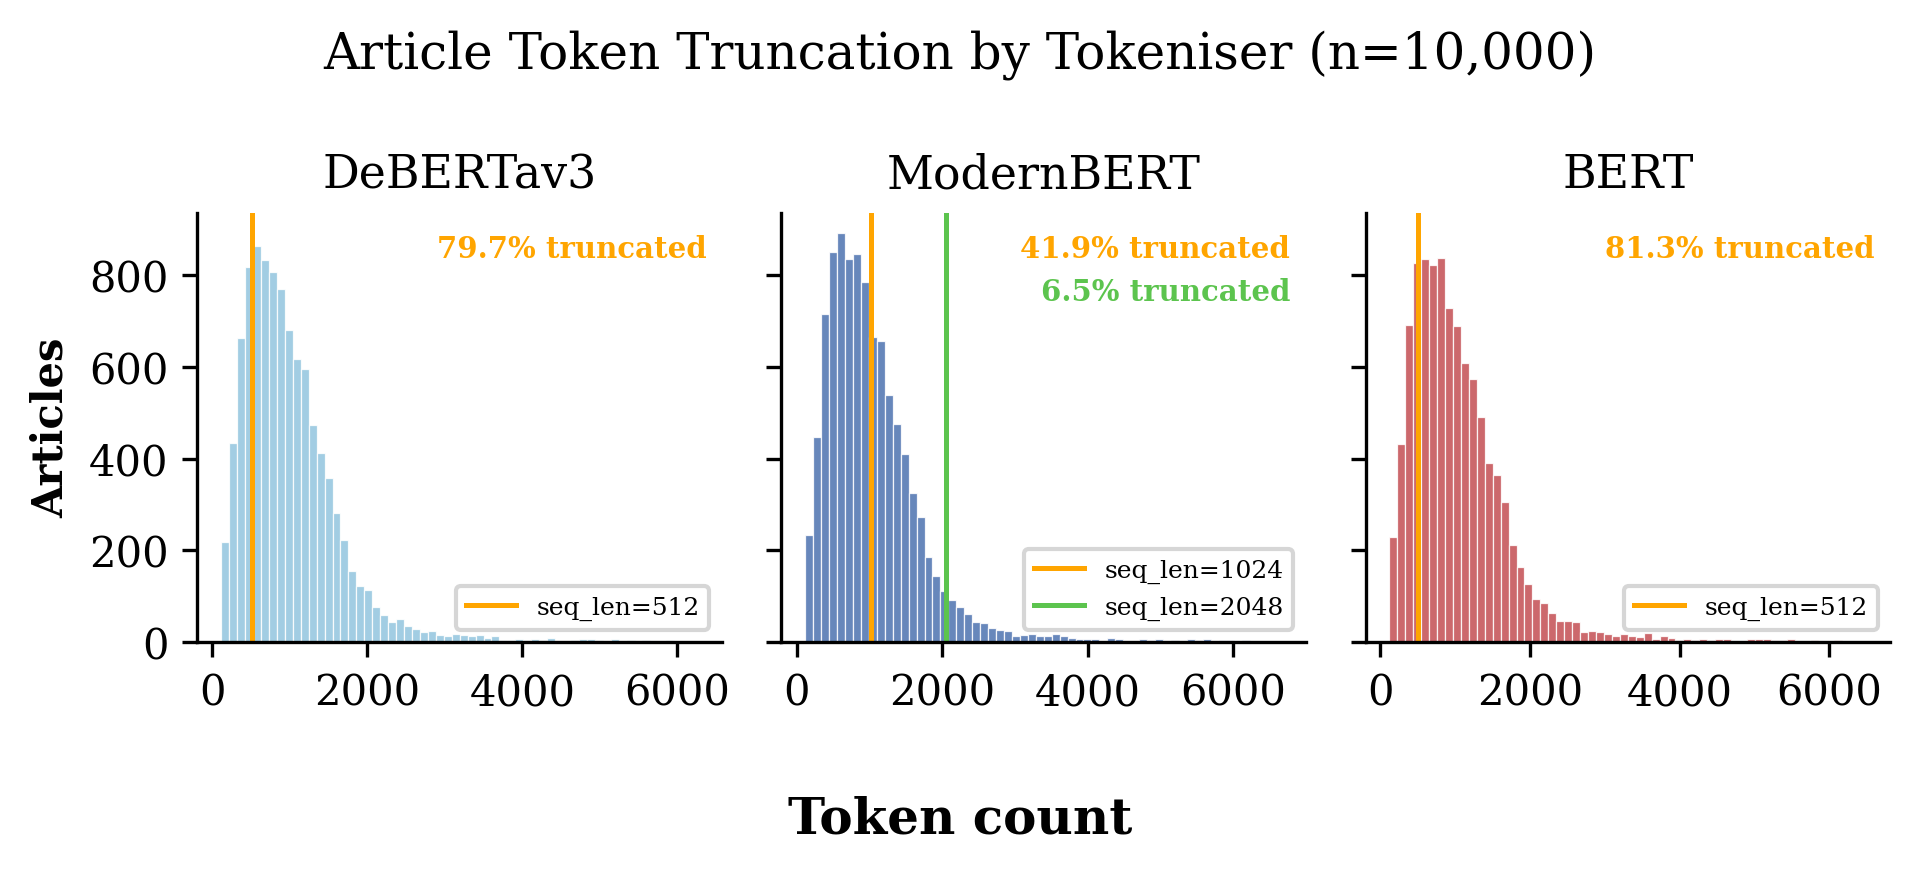

In [24]:
# Plot — one row, true distributions only
style_path = src_dir / 'figures' / 'style.mplstyle'
plt.style.use(style_path)

model_colours = {
    "DeBERTav3": Colours.LIGHT_BLUE,
    "ModernBERT": Colours.BLUE,
    "BERT": Colours.RED,
}

fig, axes = plt.subplots(1, len(MODELS), figsize=(6.5, 2.8), sharey=True)
fig.suptitle(f"Article Token Truncation by Tokeniser (n={N_SAMPLES:,})")

for i, (model_name, model_config) in enumerate(MODELS.items()):
    lengths      = true_lengths[model_name]
    sequence_len = model_config["sequence_len"]
    pct_truncated = sum(length > sequence_len for length in lengths) / N_SAMPLES
    colour = model_colours.get(model_name, Colours.GREY_LIGHT)

    axes[i].hist(lengths, bins=60, color=colour, alpha=0.85, edgecolor="white", linewidth=0.3)
    axes[i].axvline(sequence_len, color="orange", linewidth=1.2,
                    label=f"seq_len={sequence_len}")

    if model_name == "ModernBERT":
        axes[i].axvline(2048, color=Colours.GREEN, linewidth=1.2,
                label="seq_len=2048")
        pct_2048 = sum(length > 2048 for length in lengths) / N_SAMPLES
        axes[i].text(0.97, 0.85, f"{pct_2048:.1%} truncated",
             transform=axes[i].transAxes, ha="right", va="top",
             color=Colours.GREEN, fontsize=7, fontweight="bold")
        # axes[i].axvline(8192, color=Colours.GREEN, linewidth=1.2,
        #         label="seq_len=8192")
        # pct_8192 = sum(length > 8192 for length in lengths) / N_SAMPLES
        # axes[i].text(0.97, 0.75, f"{pct_8192:.1%} truncated",
        #      transform=axes[i].transAxes, ha="right", va="top",
        #      color=Colours.GREEN, fontsize=7, fontweight="bold")

    axes[i].set_title(model_name, fontweight=None)
    if i == 0:
        axes[i].set_ylabel("Articles")
    axes[i].text(0.97, 0.95, f"{pct_truncated:.1%} truncated",
                 transform=axes[i].transAxes, ha="right", va="top",
                 color="orange", fontsize=7, fontweight="bold")
    axes[i].legend(fontsize=6)

fig.supxlabel("Token count", fontweight="bold")
fig.tight_layout()
os.makedirs("../../../results/figures", exist_ok=True)
fig.savefig("../../../results/figures/token_length_analysis.png")
plt.show()